In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention Is All You Need")

"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with low latencies remains challenging due to the quadratic input length\ncomplexity of the attention layers. In this work, we investigate the effect of\ndropping MLP and attention layers at inference time o"

In [4]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=1000)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is MCP")

'Page: Model Context Protocol\nSummary: The Model Context Protocol (MCP) is an open standard, open-source framework introduced by Anthropic in November 2024 to standardize the way artificial intelligence (AI) systems like large language models (LLMs) integrate and share data with external tools, systems, and data sources. MCP provides a universal interface for reading files, executing functions, and handling contextual prompts. Following its announcement, the protocol was adopted by major AI providers, including OpenAI and Google DeepMind.\n\n'

In [6]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_ENDPOINT = os.getenv("LANGSMITH_ENDPOINT")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")
LANGSMITH_TRACING = os.getenv("LANGSMITH_TRACING", "true")
HF_TOKEN = os.getenv("HF_TOKEN")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [7]:
from langchain_tavily import TavilySearch

tavily = TavilySearch()

In [8]:
tavily.invoke("Provide me the recent AI news for July 3rd 2025")

{'query': 'Provide me the recent AI news for July 3rd 2025',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Daily Digest on AI and Emerging Technologies (3 July 2025)',
   'url': 'https://pam.int/daily-digest-on-ai-and-emerging-technologies-3-july-2025/',
   'content': 'World-first: Scientists unveil method for simulating error-corrected quantum computations (Interesting Engineering - 2 July 2025) Despite being powerful and fast, quantum computers still face challenges on their pathway to practical use cases. These devices have a limited ability to correct the arising computational errors.',
   'score': 0.8156003,
   'raw_content': None},
  {'title': "AI Progress in 2025: What's Happened and What's Next",
   'url': 'https://www.digitalbricks.ai/blog-posts/ai-progress-in-2025-whats-happened-and-whats-next',
   'content': "AI is evolving fast in 2025: bigger models, smarter agents, and global breakthroughs are shaping the future. Here's what's happe

In [9]:
tools = [arxiv, wiki, tavily]

In [10]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen-qwq-32b")
llm_with_tools = llm.bind_tools(tools)

In [11]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

pprint(llm_with_tools.invoke([HumanMessage(content=f"What is AGI?")]))

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is AGI?" I need to figure out which tool to use here. AGI stands for Artificial General Intelligence, so I should probably look up a definition or explanation. Let me check the available functions.\n\nThe tools provided are arxiv, wikipedia, and tavily_search. \n\nFirst, the arxiv function is for academic papers. But the user might want a general explanation rather than a research paper. Maybe not the best first choice.\n\nThe wikipedia function could work since Wikipedia often has good explanations of technical terms. If I search for "AGI" or "Artificial General Intelligence" on Wikipedia, that might give a clear overview. \n\nAlternatively, tavily_search could be useful if Wikipedia doesn\'t have enough info or if the user wants more current or varied sources. But since the question seems straightforward, Wikipedia might be sufficient. \n\nHmm, let me go with Wikipedia first because it\'s li

In [12]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'recent AI News',
   'search_depth': 'advanced',
   'time_range': 'week',
   'topic': 'news'},
  'id': '569cqb6b1',
  'type': 'tool_call'}]

In [13]:
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [14]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)


builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

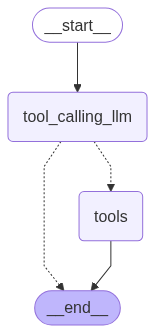

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
messages = graph.invoke({"messages": HumanMessage(content="1706.03762")})


for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (7bf86223q)
 Call ID: 7bf86223q
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks in an encoder-decoder configuration. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer, base


In [17]:
messages = graph.invoke(
    {
        "messages": HumanMessage(
            content="Provide me the top 10 recent AI news for July 3rd 2025"
        )
    }
)


for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for July 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ft2magsbm)
 Call ID: ft2magsbm
  Args:
    query: top AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "top AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://opentools.ai/news/elon-musks-xai-secures-a-whopping-dollar10-billion-funding-round", "title": "Elon Musk's xAI Secures a Whopping $10 Billion Funding Round! - OpenTools", "score": 0.60245985, "published_date": "Wed, 02 Jul 2025 14:43:43 GMT", "content": "[[Dec 24, 2024] Elon Musk's xAI Scores $6B in Funding to Supercharge AI Ambitions!](\n   [[Apr 28, 2025] Elon Musk's xAI Seeks $20 Billion to Power AI Dreams 

In [18]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="wikipedia")

In [19]:
messages = graph.invoke({"messages": HumanMessage(content="What is GenAI")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is GenAI
================================== Ai Message ==================================
Tool Calls:
  wikipedia (zsf2576kp)
 Call ID: zsf2576kp
  Args:
    query: Generative AI
================================= Tool Message =================================
Name: wikipedia

Page: Generative artificial intelligence
Summary: Generative artificial intelligence (Generative AI, GenAI, or GAI) is a subfield of artificial intelligence that uses generative models to produce text, images, videos, or other forms of data. These models learn the underlying patterns and structures of their training data and use them to produce new data based on the input, which often comes in the form of natural language prompts.
Generative AI tools have become more common since the AI boom in the 2020s. This boom was made possible by improvements in transformer-based deep neural networks, particularly large language models (LL